<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Deep%20Learning/Redes%20Neurais%20Recorrentes/Series%20Temporais/Bolsa_uma_sa%C3%ADda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import tensorflow as tf
import sklearn

In [3]:
np.__version__, pd.__version__, matplotlib.__version__, tf.__version__, sklearn.__version__

('2.0.2', '2.2.2', '3.10.0', '2.19.0', '1.6.1')

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [5]:
base = pd.read_csv("/content/petr4_treinamento.csv")
base.shape

(1245, 7)

In [6]:
base

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,19.990000,20.209999,19.690001,19.690001,18.086271,30182600.0
1,2013-01-03,19.809999,20.400000,19.700001,20.400000,18.738441,30552600.0
2,2013-01-04,20.330000,20.620001,20.170000,20.430000,18.766001,36141000.0
3,2013-01-07,20.480000,20.670000,19.950001,20.080000,18.444506,28069600.0
4,2013-01-08,20.110001,20.230000,19.459999,19.500000,17.911745,29091300.0
...,...,...,...,...,...,...,...
1240,2017-12-25,15.750000,15.750000,15.750000,15.750000,15.718563,0.0
1241,2017-12-26,15.750000,15.990000,15.690000,15.970000,15.938125,22173100.0
1242,2017-12-27,15.990000,16.139999,15.980000,16.049999,16.017963,23552200.0
1243,2017-12-28,16.100000,16.129999,16.000000,16.100000,16.067865,19011500.0


In [7]:
base.isnull().sum()

,0
Date,0
Open,3
High,3
Low,3
Close,3
Adj Close,3
Volume,3


In [8]:
base = base.dropna()

In [9]:
base.shape

(1242, 7)

In [10]:
base.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [11]:
base_treinamento = base.iloc[:, 1:2].values

In [12]:
base_treinamento

array([[19.99    ],
       [19.809999],
       [20.33    ],
       ...,
       [15.99    ],
       [16.1     ],
       [16.1     ]])

In [13]:
normalizador = MinMaxScaler(feature_range = (0, 1))
base_treinamento_normalizado = normalizador.fit_transform(base_treinamento)
base_treinamento_normalizado

array([[0.76501938],
       [0.7562984 ],
       [0.78149225],
       ...,
       [0.57122093],
       [0.57655039],
       [0.57655039]])

In [14]:
X = [] # previsores
y = [] # preço real

for i in range(90, 1242):
  X.append(base_treinamento_normalizado[i - 90:i, 0])
  y.append(base_treinamento_normalizado[i, 0])

X, y = np.array(X), np.array(y)

In [15]:
X.shape

(1152, 90)

In [16]:
y.shape

(1152,)

In [17]:
X[1], y[1]

(array([0.7562984 , 0.78149225, 0.78875969, 0.77083338, 0.74806197,
        0.75436047, 0.75823643, 0.76598837, 0.76598837, 0.76017437,
        0.75872098, 0.75581391, 0.74467054, 0.7374031 , 0.7374031 ,
        0.73498067, 0.75242248, 0.73401163, 0.71656977, 0.68120155,
        0.67538755, 0.67635659, 0.63372098, 0.66521318, 0.65649225,
        0.64680228, 0.66618222, 0.65843028, 0.64970935, 0.65116274,
        0.66424419, 0.67344961, 0.64292631, 0.64486434, 0.62257747,
        0.60949617, 0.60998067, 0.60852713, 0.59593023, 0.61143411,
        0.60222863, 0.64922481, 0.68362398, 0.70687989, 0.68265509,
        0.70978682, 0.70784879, 0.71608527, 0.73643411, 0.7122093 ,
        0.7122093 , 0.7194767 , 0.70348832, 0.69525189, 0.70397287,
        0.70397287, 0.69767442, 0.68168605, 0.68168605, 0.65310078,
        0.66618222, 0.64825581, 0.66182175, 0.64341085, 0.67877902,
        0.69137592, 0.66569772, 0.65406982, 0.64292631, 0.64147292,
        0.63565891, 0.67587209, 0.68653106, 0.70

In [18]:
regressor = Sequential()

regressor.add(LSTM(units = 100, return_sequences= True, input_shape = (X.shape[1], 1)))
regressor.add(Dropout(0.3))

regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.3))

regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.3))

regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.3))

regressor.add(Dense(units = 1, activation = "linear"))

regressor.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 90, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 90, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 90, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 90, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,451 (435.36 KB)

 Trainable params: 111,451 (435.36 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
regressor.compile(optimizer = "rmsprop", loss = "mean_squared_error", metrics = ["mean_absolute_error"])

In [20]:
regressor.fit(X, y, epochs = 100, batch_size = 32)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - loss: 0.0633 - mean_absolute_error: 0.1872
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - loss: 0.0157 - mean_absolute_error: 0.1000
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - loss: 0.0138 - mean_absolute_error: 0.0914
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step - loss: 0.0110 - mean_absolute_error: 0.0826
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 0.0107 - mean_absolute_error: 0.0814
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 183ms/step - loss: 0.0086 - mean_absolute_error: 0.0718
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - loss: 0.0091 - mean_absolute_error: 0.0734
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - loss: 0.0074 - mean_absolute_error: 0.0659
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - loss: 0.0079 - mean_absolute_error: 0.0660
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - loss: 0.0071 - mean_absolute_error: 0.0638
Epoch 11/100
36/

In [21]:
base_teste = pd.read_csv("/content/petr4_teste.csv")
base_teste

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-01-02,16.190001,16.549999,16.190001,16.549999,16.516966,33461800
1,2018-01-03,16.490000,16.719999,16.370001,16.700001,16.666668,55940900
2,2018-01-04,16.780001,16.959999,16.620001,16.730000,16.696608,37064900
3,2018-01-05,16.700001,16.860001,16.570000,16.830000,16.796408,26958200
4,2018-01-08,16.740000,17.030001,16.709999,17.030001,16.996010,28400000
5,2018-01-09,17.030001,17.160000,16.959999,17.030001,16.996010,35070900
6,2018-01-10,16.920000,17.049999,16.770000,16.799999,16.766466,28547700
7,2018-01-11,16.879999,17.299999,16.840000,17.250000,17.215569,37921500
8,2018-01-12,17.040001,17.410000,17.020000,17.299999,17.265469,45912100
9,2018-01-15,17.320000,17.440001,17.150000,17.350000,17.315371,28945400


In [22]:
base_teste.shape

(22, 7)

In [23]:
y_teste = base_teste.iloc[:, 1:2].values

In [24]:
y_teste

array([[16.190001],
       [16.49    ],
       [16.780001],
       [16.700001],
       [16.74    ],
       [17.030001],
       [16.92    ],
       [16.879999],
       [17.040001],
       [17.32    ],
       [17.35    ],
       [17.92    ],
       [18.35    ],
       [18.309999],
       [18.26    ],
       [18.4     ],
       [18.42    ],
       [19.34    ],
       [19.620001],
       [19.67    ],
       [19.77    ],
       [19.74    ]])

In [25]:
base_completa = pd.concat((base["Open"], base_teste["Open"]), axis = 0)

In [26]:
base_completa.shape

(1264,)

In [31]:
entradas = base_completa[len(base_completa) - len(base_teste) - 90:].values

In [32]:
entradas

array([13.93    , 13.76    , 13.79    , 13.53    , 13.85    , 13.96    ,
       14.57    , 14.65    , 15.02    , 15.1     , 14.88    , 14.98    ,
       14.94    , 15.03    , 15.07    , 15.02    , 15.1     , 15.25    ,
       15.85    , 15.6     , 15.79    , 15.86    , 15.7     , 15.37    ,
       15.5     , 15.19    , 15.6     , 15.9     , 15.88    , 15.66    ,
       15.61    , 16.129999, 16.17    , 16.08    , 16.23    , 16.16    ,
       16.139999, 16.219999, 16.      , 16.190001, 16.290001, 16.290001,
       16.530001, 16.780001, 16.77    , 16.969999, 16.9     , 16.99    ,
       16.9     , 16.959999, 17.049999, 17.309999, 16.690001, 16.889999,
       16.709999, 16.690001, 16.639999, 15.35    , 15.62    , 15.92    ,
       16.02    , 16.15    , 16.09    , 15.98    , 16.25    , 16.01    ,
       15.93    , 15.87    , 15.3     , 15.34    , 15.65    , 15.5     ,
       15.22    , 15.3     , 15.51    , 15.48    , 15.36    , 15.65    ,
       15.1     , 15.05    , 15.16    , 15.18    , 

In [33]:
entradas.shape

(112,)

In [34]:
entradas = entradas.reshape(-1, 1)
entradas.shape

(112, 1)

In [35]:
entradas = normalizador.transform(entradas)

In [38]:
X_teste = []
for i in range(90, 112):
  X_teste.append(entradas[i - 90: i, 0])

In [40]:
X_teste = np.array(X_teste)
X_teste = np.reshape(X_teste, (X_teste.shape[0], X_teste.shape[1], 1))

In [41]:
X_teste.shape

(22, 90, 1)

In [43]:
previsoes = regressor.predict(X_teste)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step


In [44]:
previsoes

array([[0.55617875],
       [0.5601324 ],
       [0.5643288 ],
       [0.57056016],
       [0.57733744],
       [0.58305186],
       [0.5885242 ],
       [0.59285706],
       [0.5951743 ],
       [0.5965315 ],
       [0.5992606 ],
       [0.60355955],
       [0.6117269 ],
       [0.6248994 ],
       [0.6396445 ],
       [0.65170324],
       [0.6597836 ],
       [0.6640249 ],
       [0.6708585 ],
       [0.68260664],
       [0.6966674 ],
       [0.7097225 ]], dtype=float32)

In [45]:
previsoes = normalizador.inverse_transform(previsoes)

In [46]:
previsoes

array([[15.679529],
       [15.761132],
       [15.847746],
       [15.976361],
       [16.116245],
       [16.23419 ],
       [16.34714 ],
       [16.43657 ],
       [16.484398],
       [16.51241 ],
       [16.568739],
       [16.657469],
       [16.826042],
       [17.097923],
       [17.402262],
       [17.651154],
       [17.817932],
       [17.905474],
       [18.046518],
       [18.289001],
       [18.579214],
       [18.848673]], dtype=float32)

In [47]:
y_teste

array([[16.190001],
       [16.49    ],
       [16.780001],
       [16.700001],
       [16.74    ],
       [17.030001],
       [16.92    ],
       [16.879999],
       [17.040001],
       [17.32    ],
       [17.35    ],
       [17.92    ],
       [18.35    ],
       [18.309999],
       [18.26    ],
       [18.4     ],
       [18.42    ],
       [19.34    ],
       [19.620001],
       [19.67    ],
       [19.77    ],
       [19.74    ]])

In [48]:
previsoes.mean(), y_teste.mean()

(np.float32(16.95846), np.float64(17.87454563636364))

In [50]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_teste, previsoes)

0.9160856088423297

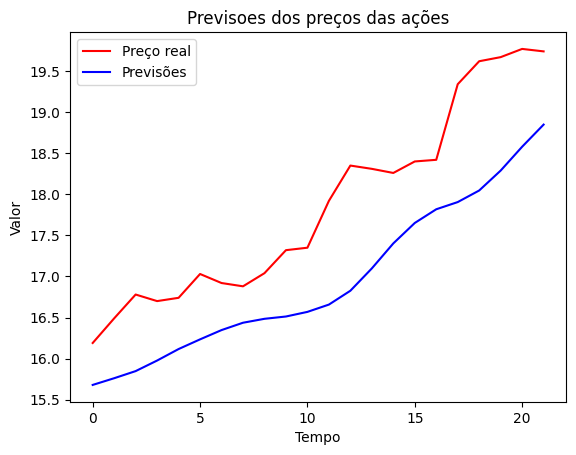

In [53]:
plt.plot(y_teste, color = "red", label = "Preço real")
plt.plot(previsoes, color = "blue", label = "Previsões")
plt.title("Previsoes dos preços das ações")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.legend();

# Multiplos previsores

In [54]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [55]:
base = pd.read_csv("/content/petr4_treinamento.csv")

In [56]:
base = base.dropna()

In [58]:
base.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,19.990000,20.209999,19.690001,19.690001,18.086271,30182600.0
1,2013-01-03,19.809999,20.400000,19.700001,20.400000,18.738441,30552600.0
2,2013-01-04,20.330000,20.620001,20.170000,20.430000,18.766001,36141000.0
3,2013-01-07,20.480000,20.670000,19.950001,20.080000,18.444506,28069600.0
4,2013-01-08,20.110001,20.230000,19.459999,19.500000,17.911745,29091300.0


In [59]:
base_treinamento = base.iloc[:, 1:7].values

In [60]:
base_treinamento

array([[1.9990000e+01, 2.0209999e+01, 1.9690001e+01, 1.9690001e+01,
        1.8086271e+01, 3.0182600e+07],
       [1.9809999e+01, 2.0400000e+01, 1.9700001e+01, 2.0400000e+01,
        1.8738441e+01, 3.0552600e+07],
       [2.0330000e+01, 2.0620001e+01, 2.0170000e+01, 2.0430000e+01,
        1.8766001e+01, 3.6141000e+07],
       ...,
       [1.5990000e+01, 1.6139999e+01, 1.5980000e+01, 1.6049999e+01,
        1.6017963e+01, 2.3552200e+07],
       [1.6100000e+01, 1.6129999e+01, 1.6000000e+01, 1.6100000e+01,
        1.6067865e+01, 1.9011500e+07],
       [1.6100000e+01, 1.6100000e+01, 1.6100000e+01, 1.6100000e+01,
        1.6067865e+01, 0.0000000e+00]])

In [61]:
normalizador = MinMaxScaler(feature_range=(0, 1))
base_treinamento_normalizado = normalizador.fit_transform(base_treinamento)
base_treinamento_normalizado

array([[0.76501938, 0.77266112, 0.79682707, 0.76080559, 0.6838135 ,
        0.04318274],
       [0.7562984 , 0.78187106, 0.79733884, 0.79567784, 0.71590949,
        0.0437121 ],
       [0.78149225, 0.79253519, 0.82139202, 0.79715132, 0.71726583,
        0.05170752],
       ...,
       [0.57122093, 0.57537562, 0.60696008, 0.58202356, 0.58202349,
        0.03369652],
       [0.57655039, 0.57489089, 0.60798362, 0.5844794 , 0.58447937,
        0.02720006],
       [0.57655039, 0.57343674, 0.61310133, 0.5844794 , 0.58447937,
        0.        ]])

In [93]:
normalizador_previsao = MinMaxScaler(feature_range=(0, 1))
normalizador_previsao.fit_transform(base_treinamento[:, 0:1])

array([[0.76501938],
       [0.7562984 ],
       [0.78149225],
       ...,
       [0.57122093],
       [0.57655039],
       [0.57655039]])

In [62]:
X = []
y = []

for i in range(90, 1242):
  X.append(base_treinamento_normalizado[i - 90: i, 0:6])
  y.append(base_treinamento_normalizado[i, 0])

X, y = np.array(X), np.array(y)

In [66]:
X.shape

(1152, 90, 6)

In [67]:
regressor = Sequential()

regressor.add(LSTM(units = 100, return_sequences= True, input_shape = (X.shape[1], 6)))
regressor.add(Dropout(0.3))

regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.3))

regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.3))

regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.3))

regressor.add(Dense(units = 1, activation = "linear"))

regressor.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 90, 100)        │        42,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 90, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 90, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 90, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 90, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 90, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,451 (443.17 KB)

 Trainable params: 113,451 (443.17 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
regressor.compile(optimizer = "adam", loss = "mean_squared_error", metrics = ["mean_absolute_error"])

In [71]:
es = EarlyStopping(monitor = "loss", min_delta = 1e-10, patience = 10, verbose = 1) # 0.00000000001
rlc = ReduceLROnPlateau(monitor = "loss", factor = 0.2, patience = 5, verbose = 1)
mcp = ModelCheckpoint(filepath = "pesos.keras", monitor = "loss", save_best_only = True, verbose = 1)

In [73]:
regressor.fit(X, y, epochs = 100, batch_size = 32, callbacks = [es, rlc, mcp])

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.0620 - mean_absolute_error: 0.1804
Epoch 1: loss improved from inf to 0.02915, saving model to pesos.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - loss: 0.0611 - mean_absolute_error: 0.1789 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.0092 - mean_absolute_error: 0.0741
Epoch 2: loss improved from 0.02915 to 0.00913, saving model to pesos.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - loss: 0.0092 - mean_absolute_error: 0.0741 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - loss: 0.0086 - mean_absolute_error: 0.0716
Epoch 3: loss improved from 0.00913 to 0.00861, saving model to pesos.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - loss: 0.0086 - mean_absolute_error: 0.0715 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 0.0074 - mean_absolute_error: 0.0648
Epoch 4: loss improved from 0.00861 to 0.00755, savi

In [74]:
base_teste = pd.read_csv("/content/petr4_teste.csv")
base_teste

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-01-02,16.190001,16.549999,16.190001,16.549999,16.516966,33461800
1,2018-01-03,16.490000,16.719999,16.370001,16.700001,16.666668,55940900
2,2018-01-04,16.780001,16.959999,16.620001,16.730000,16.696608,37064900
3,2018-01-05,16.700001,16.860001,16.570000,16.830000,16.796408,26958200
4,2018-01-08,16.740000,17.030001,16.709999,17.030001,16.996010,28400000
5,2018-01-09,17.030001,17.160000,16.959999,17.030001,16.996010,35070900
6,2018-01-10,16.920000,17.049999,16.770000,16.799999,16.766466,28547700
7,2018-01-11,16.879999,17.299999,16.840000,17.250000,17.215569,37921500
8,2018-01-12,17.040001,17.410000,17.020000,17.299999,17.265469,45912100
9,2018-01-15,17.320000,17.440001,17.150000,17.350000,17.315371,28945400


In [75]:
y_teste = base_teste.iloc[:, 1:2].values
y_teste

array([[16.190001],
       [16.49    ],
       [16.780001],
       [16.700001],
       [16.74    ],
       [17.030001],
       [16.92    ],
       [16.879999],
       [17.040001],
       [17.32    ],
       [17.35    ],
       [17.92    ],
       [18.35    ],
       [18.309999],
       [18.26    ],
       [18.4     ],
       [18.42    ],
       [19.34    ],
       [19.620001],
       [19.67    ],
       [19.77    ],
       [19.74    ]])

In [76]:
frames = [base, base_teste]

In [80]:
base_completa = pd.concat(frames)
base_completa

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,19.990000,20.209999,19.690001,19.690001,18.086271,30182600.0
1,2013-01-03,19.809999,20.400000,19.700001,20.400000,18.738441,30552600.0
2,2013-01-04,20.330000,20.620001,20.170000,20.430000,18.766001,36141000.0
3,2013-01-07,20.480000,20.670000,19.950001,20.080000,18.444506,28069600.0
4,2013-01-08,20.110001,20.230000,19.459999,19.500000,17.911745,29091300.0
...,...,...,...,...,...,...,...
17,2018-01-25,19.340000,19.340000,19.340000,19.340000,19.301397,0.0
18,2018-01-26,19.620001,19.980000,19.100000,19.930000,19.890221,81989500.0
19,2018-01-29,19.670000,20.049999,19.570000,19.850000,19.810381,55726200.0
20,2018-01-30,19.770000,19.770000,19.360001,19.490000,19.451097,46203000.0


In [83]:
base_completa = base_completa.drop("Date", axis = 1)

In [84]:
entradas = base_completa[len(base_completa) - len(base_teste) - 90:].values

In [ ]:
entradas = normalizador.transform(entradas)

In [87]:
X_teste = []
for i in range(90, 112):
  X_teste.append(entradas[i-90:i, 0:6])
X_teste = np.array(X_teste)

In [89]:
X_teste.shape

(22, 90, 6)

In [90]:
previsoes = regressor.predict(X_teste)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step


In [95]:
previsoes = normalizador_previsao.inverse_transform(previsoes)

In [96]:
previsoes.mean(), y_teste.mean()

(np.float32(17.472767), np.float64(17.87454563636364))

In [97]:
mean_absolute_error(y_teste, previsoes)

0.41280863204678603

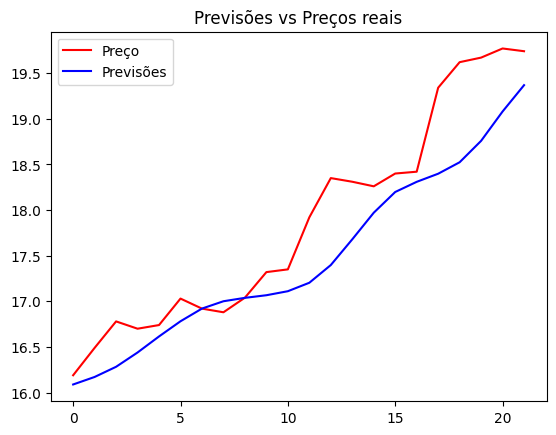

In [100]:
plt.plot(y_teste, color = "red", label = "Preço")
plt.plot(previsoes, color = 'blue', label = "Previsões")
plt.title("Previsões vs Preços reais")
plt.legend()